In [ ]:
# ── CELL 1 : INSTALLS & IMPORTS ──────────────────────────────────────────────
!pip install -q grad-cam torch torchvision scikit-learn matplotlib tqdm Pillow

import os, copy, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm
import warnings; warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve)
from sklearn.calibration import calibration_curve

# pytorch-grad-cam for HiResCAM
from pytorch_grad_cam import HiResCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASS = 2
CLASSES   = ["NORMAL", "PNEUMONIA"]
print(f"✅ Device : {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 65.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Device : cuda


In [ ]:
# ── CELL 2 : DATA → MODELS → TRAIN → ENSEMBLE → SAVE ────────────────────────

# ── 2-A  KAGGLE DATASET  ─────────────────────────────────────────────────────
# Upload your kaggle.json first, then run this block.
# If dataset is already downloaded, set DATA_ROOT manually and skip the download.

os.makedirs("/root/.kaggle", exist_ok=True)
from google.colab import files
print("Upload kaggle.json ↓")
uploaded = files.upload()
import shutil
shutil.copy(list(uploaded.keys())[0], "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip -q
DATA_ROOT = "/content/chest_xray"
print("✅ Dataset ready")

# ── 2-B  TRANSFORMS & LOADERS  ───────────────────────────────────────────────
BATCH   = 32
IMG_SZ  = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SZ, IMG_SZ)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SZ, IMG_SZ)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT,"train"), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT,"val"),   val_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_ROOT,"test"),  val_tf)

# Weighted sampler to fix class imbalance
class_counts  = np.bincount(train_ds.targets)
sample_weights = [1.0/class_counts[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,    num_workers=2, pin_memory=True)

# Class weights for loss
cw = torch.tensor([1.0/class_counts[0], 1.0/class_counts[1]], dtype=torch.float32).to(DEVICE)
cw = cw / cw.sum()
print(f"✅ Loaders ready | Train:{len(train_ds)} Val:{len(val_ds)} Test:{len(test_ds)}")

# ── 2-C  MODEL FACTORY  ──────────────────────────────────────────────────────
DROPOUT = 0.5

def build_resnet18():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(512, NUM_CLASS))
    return m

def build_resnet50():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(2048, NUM_CLASS))
    return m

def build_densenet121():
    m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(1024, NUM_CLASS))
    return m

def build_efficientnet():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(in_f, NUM_CLASS))
    return m

MODEL_BUILDERS = {
    "resnet18":    build_resnet18,
    "resnet50":    build_resnet50,
    "densenet121": build_densenet121,
    "efficientnet":build_efficientnet,
}

# HiResCAM target layer per architecture
def get_target_layer(model, name):
    if name == "resnet18":    return model.layer4[-1]
    if name == "resnet50":    return model.layer4[-1]
    if name == "densenet121": return model.features.denseblock4.denselayer16.conv2
    if name == "efficientnet":return model.features[-1]

# ── 2-D  TRAINING LOOP  ──────────────────────────────────────────────────────
EPOCHS   = 5
LR       = 1e-4
SAVE_DIR = "/content/models"
os.makedirs(SAVE_DIR, exist_ok=True)

def train_one_model(name, builder):
    print(f"\n{'='*55}\n  Training  {name.upper()}\n{'='*55}")
    model = builder().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_auc, best_state = 0.0, None
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    for epoch in range(1, EPOCHS+1):
        # ── train
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Ep{epoch} train", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tr_loss    += loss.item() * imgs.size(0)
            tr_correct += (out.argmax(1)==labels).sum().item()
            tr_total   += imgs.size(0)

        # ── validate
        model.eval()
        vl_loss, vl_correct, vl_total = 0.0, 0, 0
        all_probs, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                prob = torch.softmax(out, dim=1)[:,1].cpu().numpy()
                vl_loss    += loss.item() * imgs.size(0)
                vl_correct += (out.argmax(1)==labels).sum().item()
                vl_total   += imgs.size(0)
                all_probs.extend(prob)
                all_labels.extend(labels.cpu().numpy())

        tr_acc  = tr_correct / tr_total
        vl_acc  = vl_correct / vl_total
        tr_loss /= tr_total
        vl_loss /= vl_total
        auc      = roc_auc_score(all_labels, all_probs)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"  Ep {epoch}/{EPOCHS} | TrLoss {tr_loss:.4f} | VlLoss {vl_loss:.4f} "
              f"| TrAcc {tr_acc:.4f} | VlAcc {vl_acc:.4f} | AUC {auc:.4f}")

        if auc > best_auc:
            best_auc   = auc
            best_state = copy.deepcopy(model.state_dict())

    # save individual model
    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(SAVE_DIR, f"{name}.pth"))
    print(f"  ✅ {name} saved | Best Val AUC = {best_auc:.4f}")
    return model, best_auc, history

trained_models, auc_scores, all_histories = {}, {}, {}
for name, builder in MODEL_BUILDERS.items():
    m, auc, hist = train_one_model(name, builder)
    trained_models[name] = m
    auc_scores[name]     = auc
    all_histories[name]  = hist

print("\n🏆 Individual AUC scores:", {k:f"{v:.4f}" for k,v in auc_scores.items()})

# ── 2-E  ENSEMBLE  ───────────────────────────────────────────────────────────
class AUCWeightedEnsemble(nn.Module):
    """Soft-voting ensemble weighted by each model's validation AUC."""
    def __init__(self, models_dict, auc_dict):
        super().__init__()
        self.model_names = list(models_dict.keys())
        self.models      = nn.ModuleList([models_dict[n] for n in self.model_names])
        raw = torch.tensor([auc_dict[n] for n in self.model_names], dtype=torch.float32)
        self.weights = raw / raw.sum()          # normalise → sum to 1
        print("\n📊 Ensemble weights:")
        for n, w in zip(self.model_names, self.weights):
            print(f"   {n:15s}: {w.item():.4f}")

    def forward(self, x):
        probs = torch.stack(
            [torch.softmax(m(x), dim=1) for m in self.models], dim=0
        )  # (4, B, 2)
        w = self.weights.to(x.device).view(-1,1,1)
        return (probs * w).sum(dim=0)   # (B, 2)

    def mc_uncertainty(self, x, n_passes=30):
        """Enable dropout during inference for MC uncertainty estimation."""
        def enable_dropout(model):
            for module in model.modules():
                if isinstance(module, nn.Dropout):
                    module.train()
        self.eval()
        for m in self.models: enable_dropout(m)
        with torch.no_grad():
            passes = torch.stack(
                [self.forward(x) for _ in range(n_passes)], dim=0
            )  # (n_passes, B, 2)
        mean_prob = passes.mean(0)
        entropy   = -(mean_prob * (mean_prob + 1e-8).log()).sum(dim=1)
        return mean_prob, entropy

ensemble = AUCWeightedEnsemble(trained_models, auc_scores).to(DEVICE)

# ── 2-F  EVALUATE ENSEMBLE ON TEST SET  ──────────────────────────────────────
def evaluate(model, loader, label="Ensemble"):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"Eval {label}", leave=False):
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            prob = out[:,1].cpu().numpy()
            pred = out.argmax(1).cpu().numpy()
            all_probs.extend(prob)
            all_preds.extend(pred)
            all_labels.extend(labels.numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    auc  = roc_auc_score(all_labels, all_probs)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    spec = recall_score(all_labels, all_preds, pos_label=0)
    cm   = confusion_matrix(all_labels, all_preds)
    acc  = cm.diagonal().sum() / cm.sum()

    print(f"\n{'─'*45}")
    print(f"  {label} — TEST RESULTS")
    print(f"{'─'*45}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"  AUC-ROC     : {auc:.4f}")
    print(f"{'─'*45}")

    return {"acc":acc,"prec":prec,"rec":rec,"spec":spec,
            "f1":f1,"auc":auc,"cm":cm,"probs":all_probs,"labels":all_labels}

results = evaluate(ensemble, test_loader, "AUC-Weighted Ensemble")

# ── 2-G  SAVE ENSEMBLE  ──────────────────────────────────────────────────────
ensemble_save = {
    "model_names"   : ensemble.model_names,
    "weights"       : ensemble.weights.cpu(),
    "auc_scores"    : auc_scores,
    "state_dicts"   : {n: trained_models[n].state_dict() for n in ensemble.model_names},
}
torch.save(ensemble_save, os.path.join(SAVE_DIR, "ensemble.pth"))
print(f"✅ Ensemble saved → {SAVE_DIR}/ensemble.pth")

# Also zip for easy download
import shutil
shutil.make_archive("/content/all_models", "zip", SAVE_DIR)
print("✅ all_models.zip ready for download")

Upload kaggle.json ↓


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
✅ Dataset ready
✅ Loaders ready | Train:5216 Val:16 Test:624

  Training  RESNET18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]


  Ep 1/5 | TrLoss 0.1009 | VlLoss 0.1409 | TrAcc 0.9479 | VlAcc 1.0000 | AUC 1.0000


  Ep 2/5 | TrLoss 0.0547 | VlLoss 0.1186 | TrAcc 0.9747 | VlAcc 1.0000 | AUC 1.0000


...

  Ep 2/5 | TrLoss 0.0653 | VlLoss 0.0484 | TrAcc 0.9689 | VlAcc 1.0000 | AUC 1.0000


  Ep 3/5 | TrLoss 0.0378 | VlLoss 0.0587 | TrAcc 0.9850 | VlAcc 1.0000 | AUC 1.0000


  Ep 4/5 | TrLoss 0.0388 | VlLoss 0.0936 | TrAcc 0.9822 | VlAcc 1.0000 | AUC 1.0000


  Ep 5/5 | TrLoss 0.0287 | VlLoss 0.1472 | TrAcc 0.9881 | VlAcc 0.9375 | AUC 1.0000
  ✅ efficientnet saved | Best Val AUC = 1.0000

🏆 Individual AUC scores: {'resnet18': '1.0000', 'resnet50': '1.0000', 'densenet121': '1.0000', 'efficientnet': '1.0000'}

📊 Ensemble weights:
   resnet18       : 0.2500
   resnet50       : 0.2500
   densenet121    : 0.2500
   efficientnet   : 0.2500



─────────────────────────────────────────────
  AUC-Weighted Ensemble — TEST RESULTS
─────────────────────────────────────────────
  Accuracy    : 0.9199
  Precision   : 0.8935
  Recall      : 0.9897
  Specificity : 0.8034
  F1-Score    : 0.9392
  AUC-ROC     : 0.9747
─────────────────────────────────────────────
✅ Ensemble saved → /content/models/ensemble.pth
✅ all_models.zip ready for download


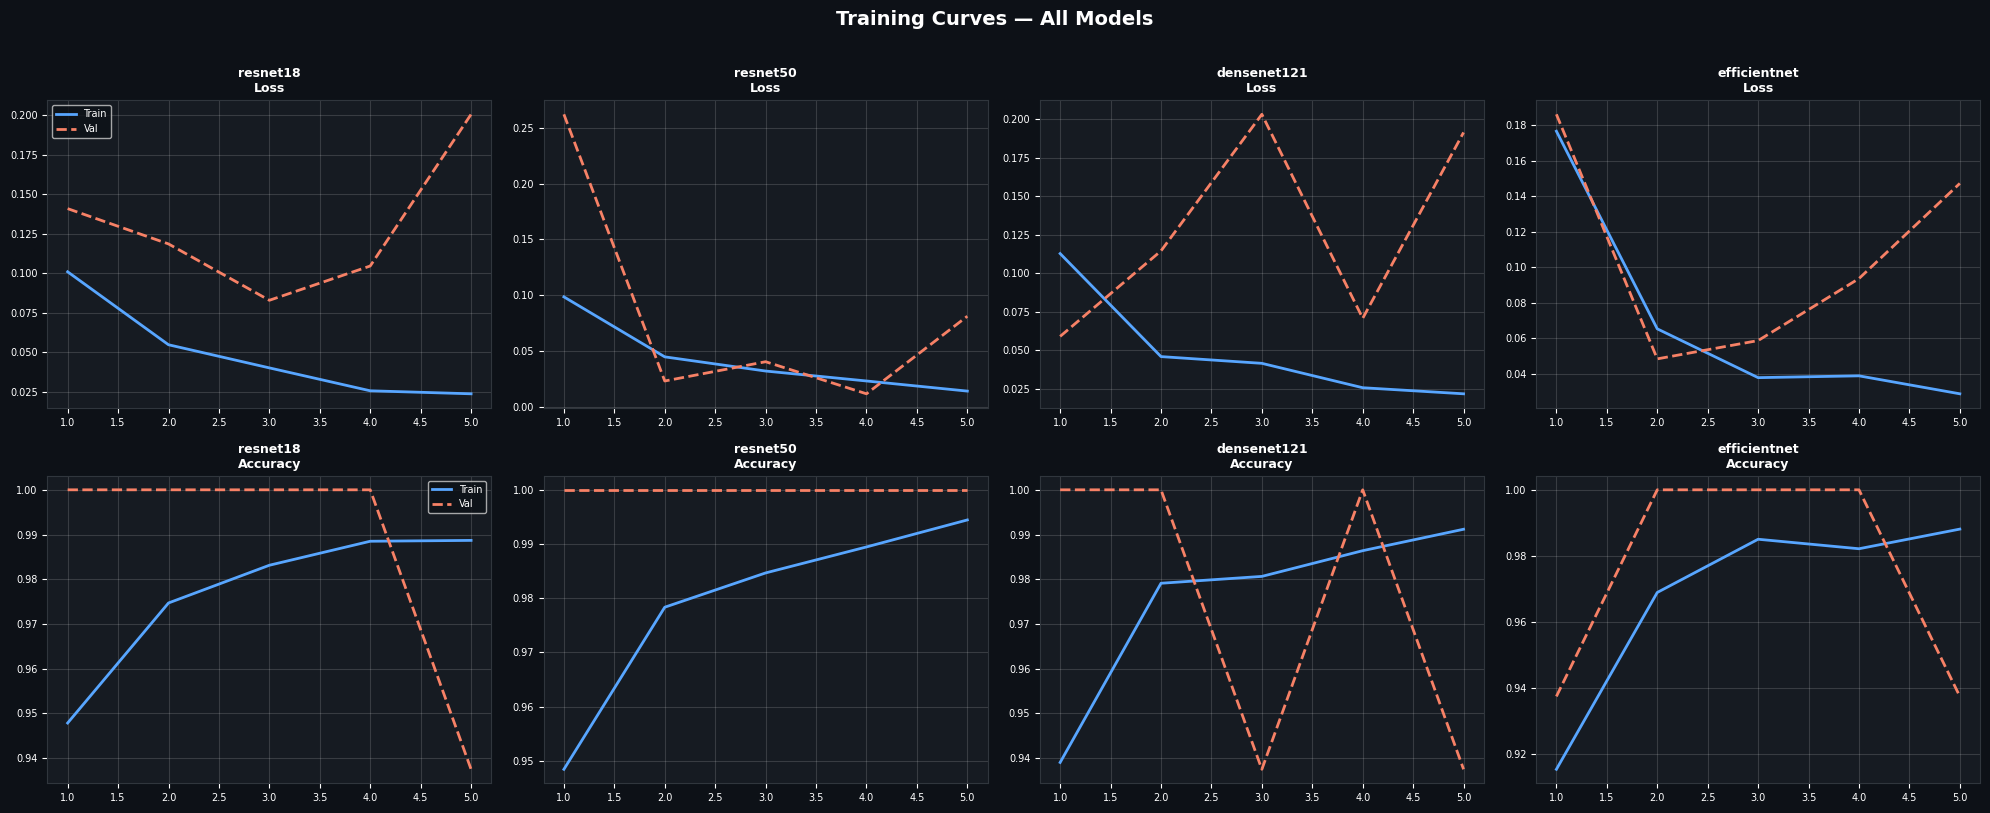


─────────────────────────────────────────────
  resnet18 — TEST RESULTS
─────────────────────────────────────────────
  Accuracy    : 0.9022
  Precision   : 0.8764
  Recall      : 0.9821
  Specificity : 0.7692
  F1-Score    : 0.9262
  AUC-ROC     : 0.9614
─────────────────────────────────────────────



─────────────────────────────────────────────
  resnet50 — TEST RESULTS
─────────────────────────────────────────────
  Accuracy    : 0.8429
  Precision   : 0.8029
  Recall      : 0.9923
  Specificity : 0.5940
  F1-Score    : 0.8876
  AUC-ROC     : 0.9656
─────────────────────────────────────────────



─────────────────────────────────────────────
  densenet121 — TEST RESULTS
─────────────────────────────────────────────
  Accuracy    : 0.9022
  Precision   : 0.8764
  Recall      : 0.9821
  Specificity : 0.7692
  F1-Score    : 0.9262
  AUC-ROC     : 0.9642
─────────────────────────────────────────────



─────────────────────────────────────────────
  efficientnet — TEST RESULTS
─────────────────────────────────────────────
  Accuracy    : 0.9215
  Precision   : 0.9031
  Recall      : 0.9795
  Specificity : 0.8248
  F1-Score    : 0.9397
  AUC-ROC     : 0.9732
─────────────────────────────────────────────


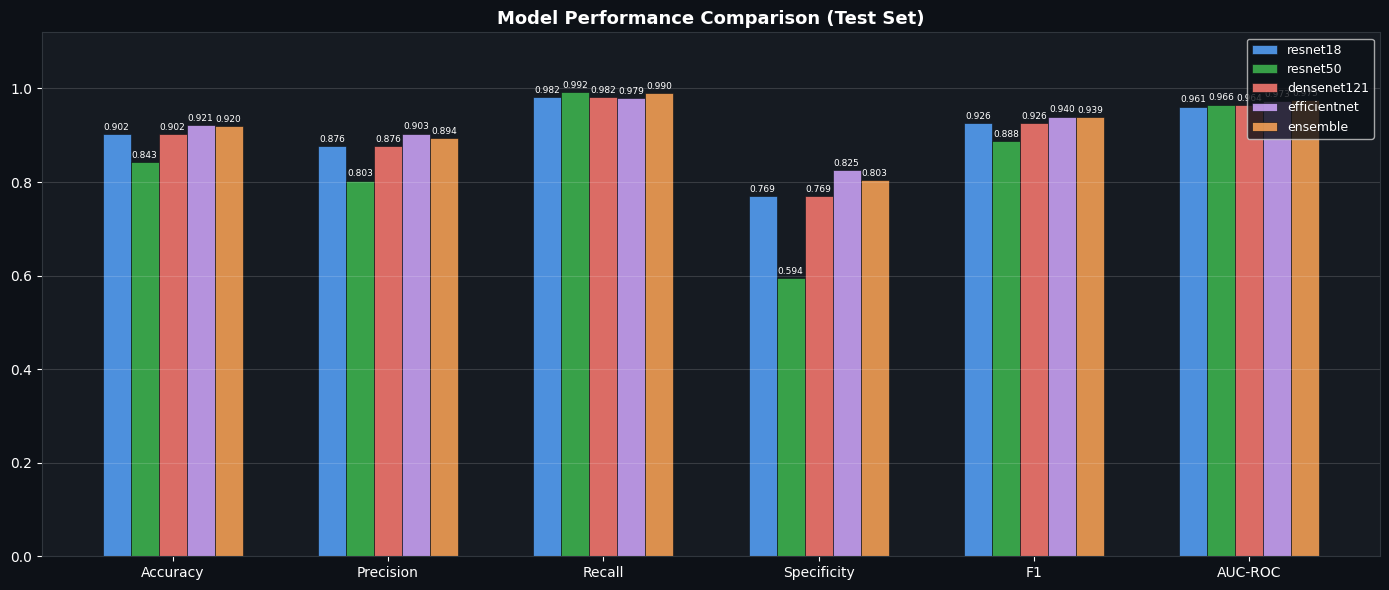

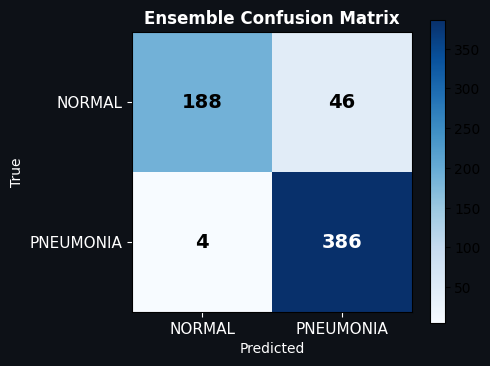

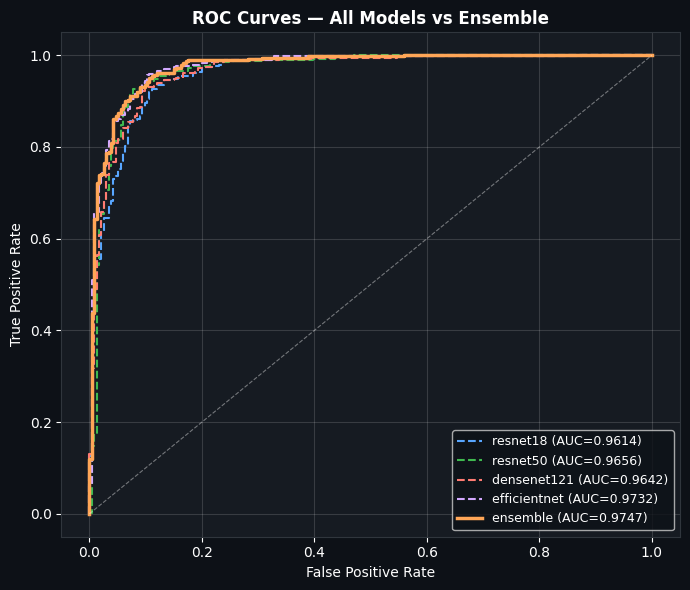


📊 Uncertainty Validation
   Avg entropy (correct) : 0.1735
   Avg entropy (wrong)   : 0.4003
   Ratio                 : 2.31×


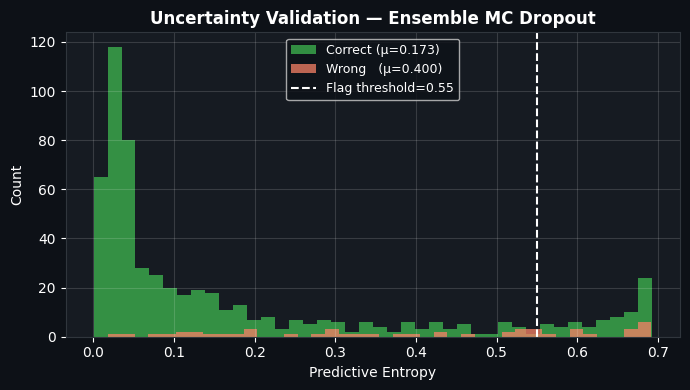

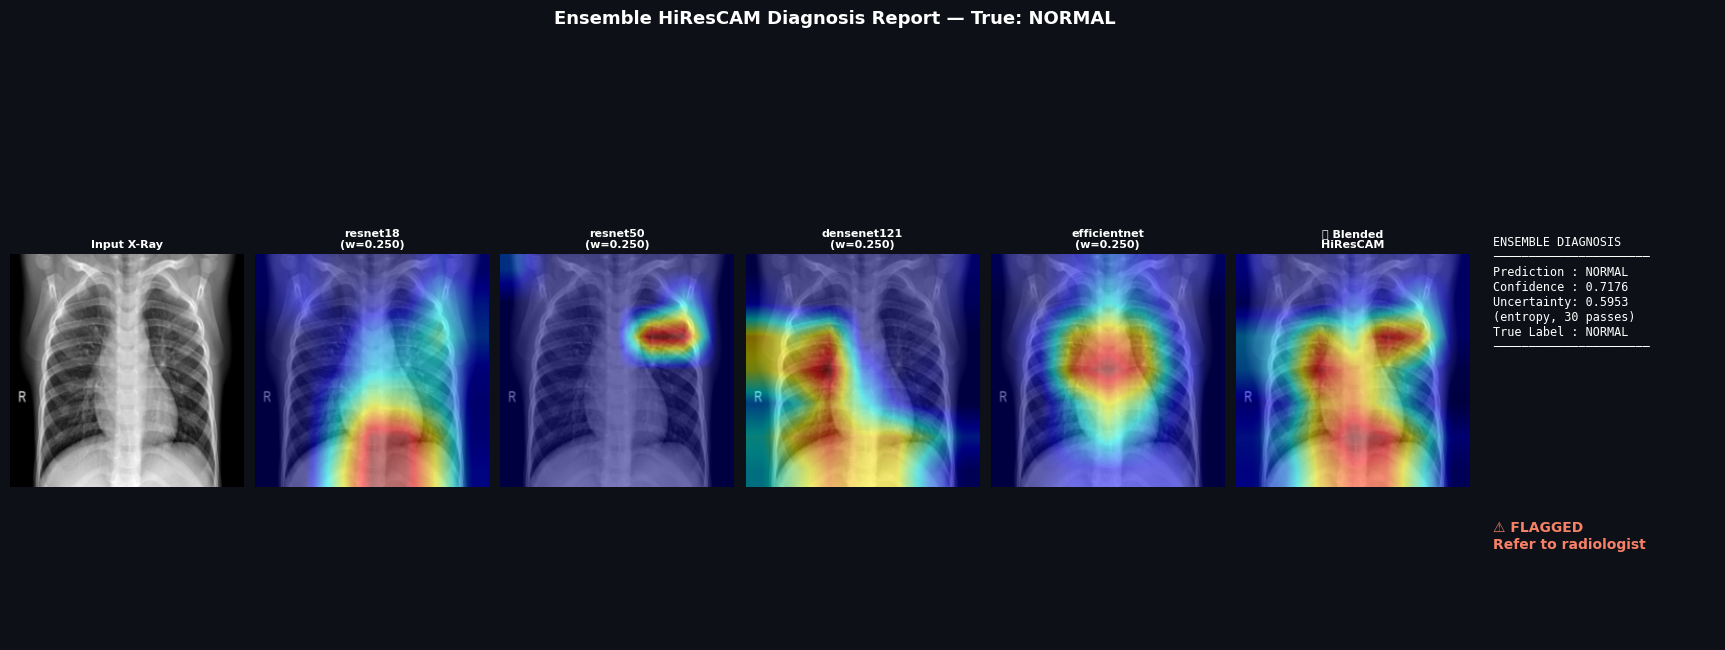

✅ Saved → /content/diagnosis_normal.png


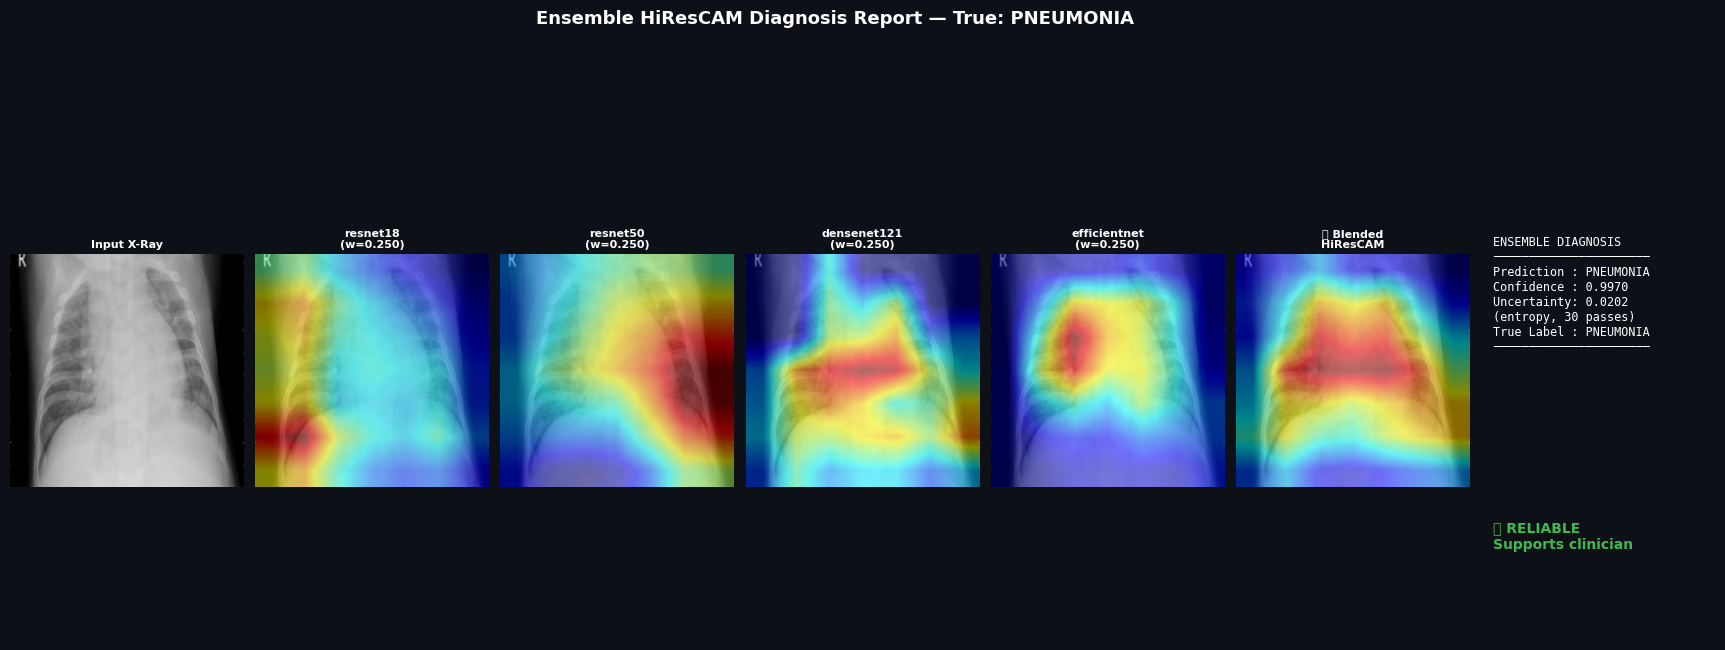

✅ Saved → /content/diagnosis_pneumonia.png

🎉 ALL DONE — Download your files from /content/
   • /content/all_models.zip  (all .pth files)
   • /content/training_curves.png
   • /content/model_comparison.png
   • /content/ensemble_confusion_matrix.png
   • /content/roc_curves.png
   • /content/uncertainty_validation.png
   • /content/diagnosis_normal.png
   • /content/diagnosis_pneumonia.png


In [ ]:
# ── CELL 3 : VISUALIZATIONS ──────────────────────────────────────────────────

ENTROPY_THRESHOLD = 0.55   # flag if entropy > this

# ── helper: denormalize tensor → numpy for display
def tensor_to_np(t):
    mean = np.array([0.485,0.456,0.406])
    std  = np.array([0.229,0.224,0.225])
    img  = t.cpu().numpy().transpose(1,2,0)
    img  = std*img + mean
    return np.clip(img, 0, 1).astype(np.float32)

# ── 3-A  TRAINING CURVES (all 4 models) ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.patch.set_facecolor("#0D1117")
for ax in axes.flatten(): ax.set_facecolor("#161B22")

colors = {"train":"#58A6FF","val":"#F78166"}

for col, (name, hist) in enumerate(all_histories.items()):
    ep = range(1, len(hist["train_loss"])+1)
    for row, (metric, label) in enumerate([("loss","Loss"),("acc","Accuracy")]):
        ax = axes[row][col]
        ax.plot(ep, hist[f"train_{metric}"], color=colors["train"], lw=2, label="Train")
        ax.plot(ep, hist[f"val_{metric}"],   color=colors["val"],   lw=2, label="Val", ls="--")
        ax.set_title(f"{name}\n{label}", color="white", fontsize=9, fontweight="bold")
        ax.tick_params(colors="white", labelsize=7)
        for spine in ax.spines.values(): spine.set_edgecolor("#30363D")
        ax.grid(alpha=0.15, color="white")
        if col == 0: ax.legend(fontsize=7, facecolor="#0D1117", labelcolor="white")

fig.suptitle("Training Curves — All Models", color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

# ── 3-B  MODEL COMPARISON BAR CHART  ─────────────────────────────────────────
indiv_results = {}
for name, model in trained_models.items():
    indiv_results[name] = evaluate(model, test_loader, name)
indiv_results["ensemble"] = results

metrics_list = ["acc","prec","rec","spec","f1","auc"]
metric_labels = ["Accuracy","Precision","Recall","Specificity","F1","AUC-ROC"]
model_names_plot = list(indiv_results.keys())
palette = ["#58A6FF","#3FB950","#FF7B72","#D2A8FF","#FFA657","#F78166"]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#161B22")
x = np.arange(len(metrics_list))
bar_w = 0.13
for i, (mname, res) in enumerate(indiv_results.items()):
    vals = [res[m] for m in metrics_list]
    bars = ax.bar(x + i*bar_w, vals, bar_w, label=mname,
                  color=palette[i], alpha=0.85, edgecolor="#0D1117", lw=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=6.5, color="white")

ax.set_xticks(x + bar_w*2)
ax.set_xticklabels(metric_labels, color="white", fontsize=10)
ax.set_ylim(0, 1.12)
ax.tick_params(colors="white")
ax.set_title("Model Performance Comparison (Test Set)", color="white", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, facecolor="#0D1117", labelcolor="white", loc="upper right")
for spine in ax.spines.values(): spine.set_edgecolor("#30363D")
ax.grid(axis="y", alpha=0.15, color="white")
plt.tight_layout()
plt.savefig("/content/model_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

# ── 3-C  CONFUSION MATRIX — ENSEMBLE  ────────────────────────────────────────
cm = results["cm"]
fig, ax = plt.subplots(figsize=(5,4))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASSES, color="white", fontsize=11)
ax.set_yticklabels(CLASSES, color="white", fontsize=11)
ax.set_xlabel("Predicted", color="white"); ax.set_ylabel("True", color="white")
ax.set_title("Ensemble Confusion Matrix", color="white", fontsize=12, fontweight="bold")
ax.tick_params(colors="white")
for (r,c), v in np.ndenumerate(cm):
    ax.text(c, r, str(v), ha="center", va="center",
            color="white" if v > cm.max()/2 else "black", fontsize=14, fontweight="bold")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("/content/ensemble_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

# ── 3-D  ROC CURVES — ALL MODELS + ENSEMBLE  ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7,6))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#161B22")
for col, (mname, res) in zip(palette, indiv_results.items()):
    fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
    lw = 2.5 if mname=="ensemble" else 1.5
    ls = "-" if mname=="ensemble" else "--"
    ax.plot(fpr, tpr, color=col, lw=lw, ls=ls, label=f"{mname} (AUC={res['auc']:.4f})")
ax.plot([0,1],[0,1],"w--",lw=0.8,alpha=0.4)
ax.set_xlabel("False Positive Rate", color="white")
ax.set_ylabel("True Positive Rate",  color="white")
ax.set_title("ROC Curves — All Models vs Ensemble", color="white", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, facecolor="#0D1117", labelcolor="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#30363D")
ax.grid(alpha=0.15, color="white")
plt.tight_layout()
plt.savefig("/content/roc_curves.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

# ── 3-E  UNCERTAINTY VALIDATION (Entropy: correct vs wrong predictions) ───────
ensemble.eval()
all_entropy, all_correct = [], []
for imgs, labels in tqdm(test_loader, desc="MC Uncertainty", leave=False):
    imgs = imgs.to(DEVICE)
    mean_prob, entropy = ensemble.mc_uncertainty(imgs, n_passes=30)
    preds = mean_prob.argmax(1).cpu().numpy()
    correct = (preds == labels.numpy())
    all_entropy.extend(entropy.cpu().numpy())
    all_correct.extend(correct)

all_entropy = np.array(all_entropy)
all_correct = np.array(all_correct)
ent_correct = all_entropy[all_correct]
ent_wrong   = all_entropy[~all_correct]

print(f"\n📊 Uncertainty Validation")
print(f"   Avg entropy (correct) : {ent_correct.mean():.4f}")
print(f"   Avg entropy (wrong)   : {ent_wrong.mean():.4f}")
print(f"   Ratio                 : {ent_wrong.mean()/ent_correct.mean():.2f}×")

fig, ax = plt.subplots(figsize=(7,4))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#161B22")
ax.hist(ent_correct, bins=40, alpha=0.75, color="#3FB950", label=f"Correct (μ={ent_correct.mean():.3f})")
ax.hist(ent_wrong,   bins=40, alpha=0.75, color="#F78166", label=f"Wrong   (μ={ent_wrong.mean():.3f})")
ax.axvline(ENTROPY_THRESHOLD, color="white", ls="--", lw=1.5, label=f"Flag threshold={ENTROPY_THRESHOLD}")
ax.set_xlabel("Predictive Entropy", color="white")
ax.set_ylabel("Count",              color="white")
ax.set_title("Uncertainty Validation — Ensemble MC Dropout", color="white", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, facecolor="#0D1117", labelcolor="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#30363D")
ax.grid(alpha=0.15, color="white")
plt.tight_layout()
plt.savefig("/content/uncertainty_validation.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

# ── 3-F  HiResCAM ENSEMBLE DIAGNOSIS PANEL  ──────────────────────────────────
# Shows: Input | HiResCAM per model (×4) | Blended HiResCAM | Report
# Pulls 1 NORMAL + 1 PNEUMONIA sample from test set

def get_sample(dataset, label_idx):
    """Return (tensor, pil_img) for first sample of given class."""
    for img_t, lbl in DataLoader(dataset, batch_size=1, shuffle=True):
        if lbl.item() == label_idx:
            return img_t, Image.open(dataset.imgs[0][0]).convert("RGB")
    return None, None

def blend_heatmaps(heatmaps, weights):
    """Weighted blend of multiple HiResCAM heatmaps."""
    h = np.zeros_like(heatmaps[0], dtype=np.float32)
    for hm, w in zip(heatmaps, weights):
        h += w * hm
    h = (h - h.min()) / (h.max() - h.min() + 1e-8)
    return h

def run_ensemble_diagnosis(img_tensor, true_label_str):
    """Full diagnosis: MC uncertainty + per-model HiResCAM + blended heatmap."""
    img_tensor = img_tensor.to(DEVICE)
    rgb_np     = tensor_to_np(img_tensor[0])

    # MC Uncertainty
    mean_prob, entropy = ensemble.mc_uncertainty(img_tensor, n_passes=30)
    pred_idx    = mean_prob.argmax(1).item()
    confidence  = mean_prob[0, pred_idx].item()
    unc_val     = entropy[0].item()
    flagged     = unc_val > ENTROPY_THRESHOLD
    pred_label  = CLASSES[pred_idx]

    # Per-model HiResCAM
    heatmaps = []
    norm_weights = ensemble.weights.numpy()
    cams_per_model = []

    for name, model, w in zip(ensemble.model_names, ensemble.models, norm_weights):
        tgt_layer = get_target_layer(model, name)
        cam = HiResCAM(model=model, target_layers=[tgt_layer])
        targets = [ClassifierOutputTarget(pred_idx)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]  # H×W
        heatmaps.append(grayscale_cam)
        overlay = show_cam_on_image(rgb_np, grayscale_cam, use_rgb=True)
        cams_per_model.append((name, overlay, w))

    blended = blend_heatmaps(heatmaps, norm_weights)
    blended_overlay = show_cam_on_image(rgb_np, blended, use_rgb=True)

    # ── Plot
    fig = plt.figure(figsize=(22, 7))
    fig.patch.set_facecolor("#0D1117")
    gs  = gridspec.GridSpec(1, 7, figure=fig, wspace=0.05)

    def show(ax, img, title, border=None):
        ax.imshow(img)
        ax.set_title(title, color="white", fontsize=8, fontweight="bold", pad=4)
        ax.axis("off")
        if border:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border)
                spine.set_linewidth(3)

    show(fig.add_subplot(gs[0]), rgb_np, "Input X-Ray")
    for i, (name, overlay, w) in enumerate(cams_per_model):
        show(fig.add_subplot(gs[i+1]), overlay, f"{name}\n(w={w:.3f})")
    show(fig.add_subplot(gs[5]), blended_overlay, "🔀 Blended\nHiResCAM",
         border="#58A6FF")

    # Report panel
    ax_r = fig.add_subplot(gs[6])
    ax_r.set_facecolor("#161B22")
    ax_r.axis("off")
    status_color = "#F78166" if flagged else "#3FB950"
    status_text  = "⚠ FLAGGED\nRefer to radiologist" if flagged else "✅ RELIABLE\nSupports clinician"
    report = (
        f"ENSEMBLE DIAGNOSIS\n"
        f"{'─'*22}\n"
        f"Prediction : {pred_label}\n"
        f"Confidence : {confidence:.4f}\n"
        f"Uncertainty: {unc_val:.4f}\n"
        f"(entropy, 30 passes)\n"
        f"True Label : {true_label_str}\n"
        f"{'─'*22}\n"
    )
    ax_r.text(0.05, 0.75, report, color="white", fontsize=8.5,
              va="top", fontfamily="monospace", transform=ax_r.transAxes)
    ax_r.text(0.05, 0.22, status_text, color=status_color, fontsize=10,
              fontweight="bold", va="top", transform=ax_r.transAxes)

    fig.suptitle(f"Ensemble HiResCAM Diagnosis Report — True: {true_label_str}",
                 color="white", fontsize=13, fontweight="bold", y=1.01)
    fname = f"/content/diagnosis_{true_label_str.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor="#0D1117")
    plt.show()
    print(f"✅ Saved → {fname}")

# Run for one NORMAL and one PNEUMONIA sample
for label_idx, label_str in [(0,"NORMAL"), (1,"PNEUMONIA")]:
    for img_t, lbl in DataLoader(test_ds, batch_size=1, shuffle=True):
        if lbl.item() == label_idx:
            run_ensemble_diagnosis(img_t, label_str)
            break

print("\n🎉 ALL DONE — Download your files from /content/")
print("   • /content/all_models.zip  (all .pth files)")
print("   • /content/training_curves.png")
print("   • /content/model_comparison.png")
print("   • /content/ensemble_confusion_matrix.png")
print("   • /content/roc_curves.png")
print("   • /content/uncertainty_validation.png")
print("   • /content/diagnosis_normal.png")
print("   • /content/diagnosis_pneumonia.png")